### Testing script of the CNN model
#### TODO:
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters
+ Data Augmentation options!!
+ Check whether CNN model can handle different image sizes (but good news, our datasets are at least all square images)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN
from data.load_cifar import CIFAR10
from train import train_model

# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:
# Create datasets
train_dataset = CIFAR10(split="train")
test_dataset  = CIFAR10(split="test")

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Train samples: 50000
Test samples: 10000


/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")


In [3]:
# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)


/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [4]:
model = SimpleCNN(
    in_channels=3,
    num_classes=10,
    input_size=32,
    base_channels=32,
    channel_multiplier=2
)

model = model.to(device)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [5]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)


Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6637 | Train Acc: 0.3892
Train Time: 48.77s
Val   Loss: 1.3416 | Val   Acc: 0.5151
Val   Time: 15.00s

Epoch 2/10


Train Loss: 1.3243 | Train Acc: 0.5224
Train Time: 43.66s
Val   Loss: 1.1917 | Val   Acc: 0.5774
Val   Time: 14.12s

Epoch 3/10


Train Loss: 1.1712 | Train Acc: 0.5831
Train Time: 43.34s
Val   Loss: 1.0613 | Val   Acc: 0.6259
Val   Time: 13.88s

Epoch 4/10


...

Train Loss: 0.8769 | Train Acc: 0.6917
Train Time: 44.12s
Val   Loss: 0.8244 | Val   Acc: 0.7092
Val   Time: 13.86s

Epoch 7/10


Train Loss: 0.8148 | Train Acc: 0.7146
Train Time: 42.91s
Val   Loss: 0.8191 | Val   Acc: 0.7123
Val   Time: 14.14s

Epoch 8/10


Train Loss: 0.7537 | Train Acc: 0.7345
Train Time: 43.59s
Val   Loss: 0.7731 | Val   Acc: 0.7307
Val   Time: 14.00s

Epoch 9/10


Train Loss: 0.7078 | Train Acc: 0.7509
Train Time: 43.23s
Val   Loss: 0.7580 | Val   Acc: 0.7310
Val   Time: 13.82s

Epoch 10/10


Train Loss: 0.6578 | Train Acc: 0.7708
Train Time: 41.91s
Val   Loss: 0.7663 | Val   Acc: 0.7299
Val   Time: 13.59s

Total Training Time  : 439.80s
Total Validation Time: 140.62s


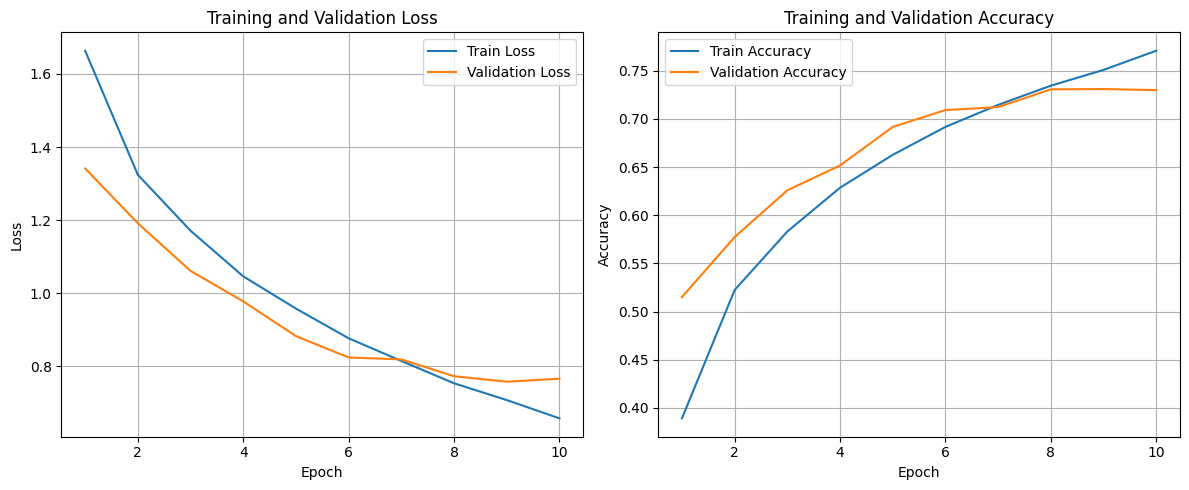

<Figure size 640x480 with 0 Axes>

In [6]:
trained_model = train_model(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=10
)

In [7]:
# save the trained model
file_name = "simple_cnn_cifar10_v2.pth"
torch.save(trained_model.state_dict(), file_name)
#del trained_model

In [8]:
# load the saved model with the same parameters initially set
trained_model = SimpleCNN(in_channels=3, num_classes=10, input_size=32, base_channels=32, channel_multiplier=2)
trained_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [9]:
trained_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

print(f"Final validation accuracy: {correct / total:.4f}")


Final validation accuracy: 0.7299


In [10]:
from analysis.evaluation import evaluate_model

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Model Evaluation
----------------
Overall accuracy: 0.7299

Per-class accuracy:
  airplane: 0.861
automobile: 0.890
      bird: 0.627
       cat: 0.534
      deer: 0.649
       dog: 0.521
      frog: 0.822
     horse: 0.799
      ship: 0.852
     truck: 0.744

Classification report:
              precision    recall  f1-score   support

    airplane      0.643     0.861     0.736      1000
  automobile      0.807     0.890     0.846      1000
        bird      0.637     0.627     0.632      1000
         cat      0.554     0.534     0.544      1000
        deer      0.720     0.649     0.682      1000
         dog      0.719     0.521     0.604      1000
        frog      0.800     0.822     0.811      1000
       horse      0.757     0.799     0.778      1000
        ship      0.824     0.852     0.838      1000
       truck      0.859     0.744     0.797      1000

    accuracy                          0.730     10000
   macro avg      0.732     0.730     0.727     10000
weighted av

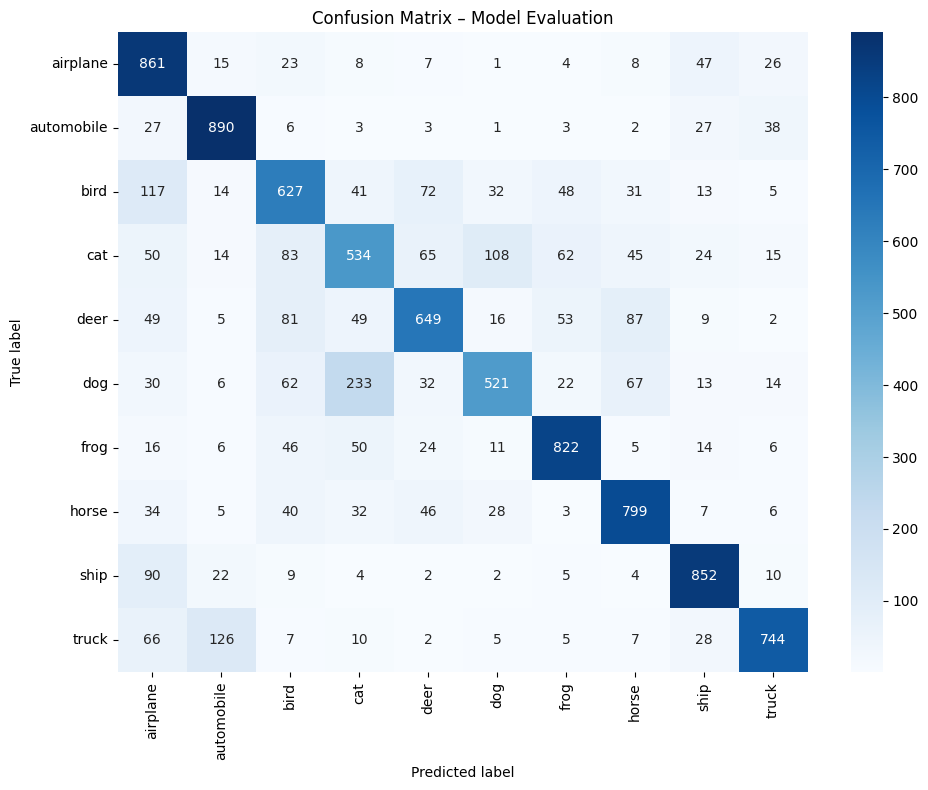

{'overall_accuracy': 0.7299000024795532,
 'per_class_accuracy': array([0.861, 0.89 , 0.627, 0.534, 0.649, 0.521, 0.822, 0.799, 0.852,
        0.744]),
 'confusion_matrix': array([[861,  15,  23,   8,   7,   1,   4,   8,  47,  26],
        [ 27, 890,   6,   3,   3,   1,   3,   2,  27,  38],
        [117,  14, 627,  41,  72,  32,  48,  31,  13,   5],
        [ 50,  14,  83, 534,  65, 108,  62,  45,  24,  15],
        [ 49,   5,  81,  49, 649,  16,  53,  87,   9,   2],
        [ 30,   6,  62, 233,  32, 521,  22,  67,  13,  14],
        [ 16,   6,  46,  50,  24,  11, 822,   5,  14,   6],
        [ 34,   5,  40,  32,  46,  28,   3, 799,   7,   6],
        [ 90,  22,   9,   4,   2,   2,   5,   4, 852,  10],
        [ 66, 126,   7,  10,   2,   5,   5,   7,  28, 744]]),
 'predictions': tensor([3, 8, 8,  ..., 5, 4, 7]),
 'labels': tensor([3, 8, 8,  ..., 5, 1, 7])}

In [11]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]
evaluate_model(trained_model, valloader, device="cpu", class_names=class_names)